# Experiment 3: Comparing model performance as number of parameters changes

In this experiment, we'll evaluate how model accuracy depends on the size of the model. We'll again use three simple CV datasets, MNIST, Fashion-MNIST, and CIFAR-10. 

We'll scale both the number of layers (keeping the model width fixed), as well as the model width (keeping the number of layers fixed). We'll then plot both on a log-linear plot to see how the model size and shape influences model performance (measured through validation accuracy) on these simple benchmark datasets.

#### Imports and Setup

In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..')) # Adjust as needed
if project_root not in sys.path:
    sys.path.append(project_root) # add notebook to sys.path

In [2]:
import torch
import matplotlib.pyplot as plt

from utils.train import fit, val_stats, load_model
from utils.hparams import (MLPHyperParameters, 
                         CNNHyperParameters)

In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


#### Model Sizes

In [4]:
N_layer = 5
N_width = 7

num_layers_sweep = list(range(1,1+N_layer))
print(num_layers_sweep)

model_width_sweep = [2**i for i in range(N_width)]
print(model_width_sweep)

[1, 2, 3, 4, 5]
[1, 2, 4, 8, 16, 32, 64]


In [5]:
mlp_val_accuracies = [[[],[],[]],[[],[],[]]]
cnn_val_accuracies = [[[],[],[]],[[],[],[]]]

#### Compute number of parameters

In [6]:
def get_hp(model_name, dataset, **kwargs):
    match model_name:
        case 'MLP':
            return MLPHyperParameters(dataset=dataset, 
                                      id=f'{dataset} {model_name}, {kwargs}', 
                                      **kwargs)
        case 'CNN':
            return CNNHyperParameters(dataset=dataset, 
                                      id=f'{dataset} {model_name}, {kwargs}', 
                                      **kwargs)
        case _:
            raise ValueError(f"Model name {model_name} is unspecified")

In [7]:
mlp_num_params = [[[],[],[]], [[],[],[]]]
cnn_num_params = [[[],[],[]], [[],[],[]]]
dataset_names = ['MNIST', 'FashionMNIST', 'CIFAR10']

# Sweep 1

for num_layers in num_layers_sweep:
    for i, ds_name in enumerate(dataset_names):
        mlp_hp = get_hp('MLP', ds_name, num_layers=num_layers)
        cnn_hp = get_hp('CNN', ds_name, num_convs=num_layers)
        mlp = load_model(mlp_hp)
        cnn = load_model(cnn_hp)
        if ds_name == 'MNIST':
            print(cnn)
        mlp_num_params[0][i].append(mlp.num_params)
        cnn_num_params[0][i].append(cnn.num_params)

# Sweep 2
for model_width in model_width_sweep:
    for i, ds_name in enumerate(dataset_names):
        mlp_hp = get_hp('MLP', ds_name, hidden_width=model_width)
        cnn_hp = get_hp('CNN', ds_name, channel_width=model_width)
        mlp = load_model(mlp_hp)
        cnn = load_model(cnn_hp)
        if ds_name == 'MNIST':
            print(cnn)
        mlp_num_params[1][i].append(mlp.num_params)
        cnn_num_params[1][i].append(cnn.num_params)

plt.close('all')

CNN(
  (convs): ModuleList(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (fc_hidden): Linear(in_features=1568, out_features=128, bias=True)
  (fc_out): Linear(in_features=128, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
CNN(
  (convs): ModuleList(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(8, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (fc_hidden): Linear(in_features=1568, out_features=128, bias=True)
  (fc_out): Linear(in_features=128, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
CNN(
  (convs): ModuleList(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(8, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (fc_hidden): Linear(

/Users/nickmcgreivy/code/ml-practice/ml-experiments/utils/plot.py:64: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 2, figsize=(7, 3))


CNN(
  (convs): ModuleList(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(8, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (fc_hidden): Linear(in_features=1568, out_features=128, bias=True)
  (fc_out): Linear(in_features=128, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
CNN(
  (convs): ModuleList(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (fc_hidden): Linear(in_features=3136, out_features=128, bias=True)
  (fc_out): Linear(in_features=128, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
CNN(
  (convs): ModuleList(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(32, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (fc_hidden): Lin

In [8]:
print(mlp_num_params[0])
print(mlp_num_params[1])

[[50890, 55050, 59210, 63370, 67530], [50890, 55050, 59210, 63370, 67530], [197322, 201482, 205642, 209802, 213962]]
[[809, 1612, 3230, 6514, 13274, 27562, 59210], [809, 1612, 3230, 6514, 13274, 27562, 59210], [3097, 6188, 12382, 24818, 49882, 100778, 205642]]


In [9]:
print(cnn_num_params[0])
print(cnn_num_params[1])

[[202202, 204538, 213786, 223034, 232282], [202202, 204538, 213786, 223034, 232282], [263786, 266122, 275370, 284618, 293866]]
[[26556, 51766, 102402, 204538, 412266, 841546, 1755402], [26556, 51766, 102402, 204538, 412266, 841546, 1755402], [34254, 67162, 133194, 266122, 535434, 1087882, 2248074]]


### MNIST Experiments

Sweep 1

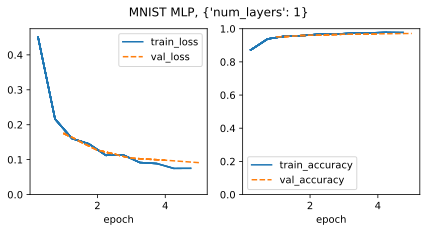

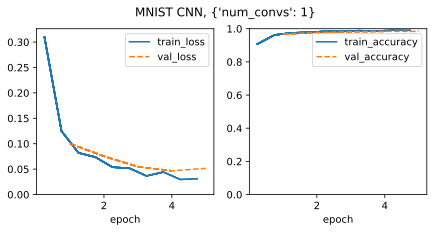

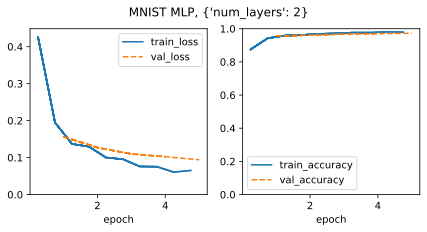

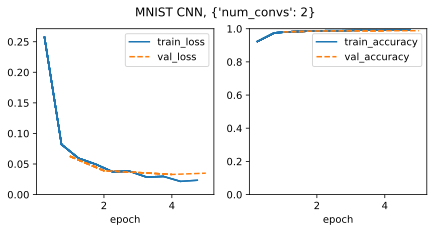

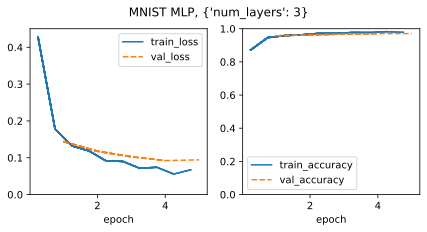

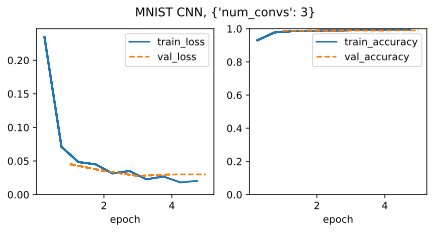

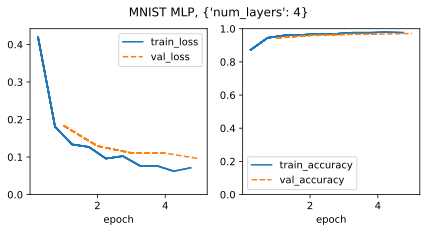

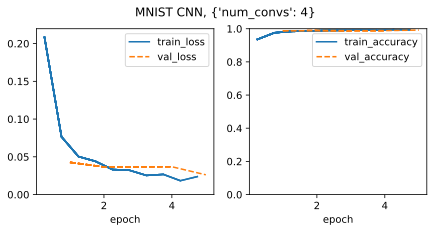

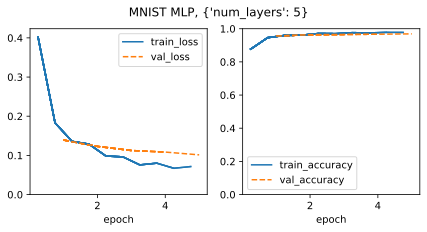

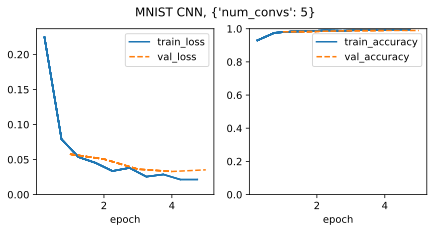

In [10]:
for num_layers in num_layers_sweep:
    mlp_hp = get_hp('MLP', 'MNIST', num_layers=num_layers)
    cnn_hp = get_hp('CNN', 'MNIST', num_convs=num_layers)
    mlp_model = fit(mlp_hp, device=device)
    cnn_model = fit(cnn_hp, device=device)
    _, mlp_val_accuracy = val_stats(mlp_model, mlp_hp, device=device)
    _, cnn_val_accuracy = val_stats(cnn_model, cnn_hp, device=device)
    mlp_val_accuracies[0][0].append(mlp_val_accuracy)
    cnn_val_accuracies[0][0].append(cnn_val_accuracy)
plt.show()

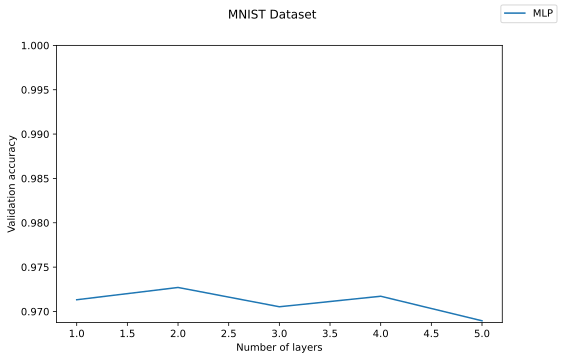

In [11]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(num_layers_sweep, mlp_val_accuracies[0][0], label="MLP")
axs.set_xlabel("Number of layers")
axs.set_ylabel("Validation accuracy")
axs.set_ylim([None,1])
fig.suptitle('MNIST Dataset')
fig.legend();

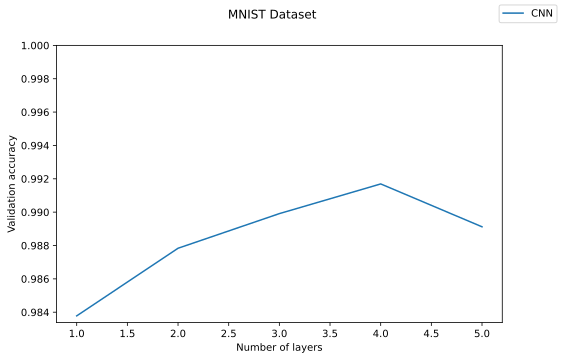

In [12]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(num_layers_sweep, cnn_val_accuracies[0][0], label="CNN")
axs.set_xlabel("Number of layers")
axs.set_ylabel("Validation accuracy")
axs.set_ylim([None,1])
fig.suptitle('MNIST Dataset')
fig.legend();

Sweep 2

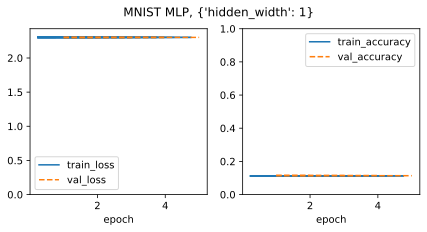

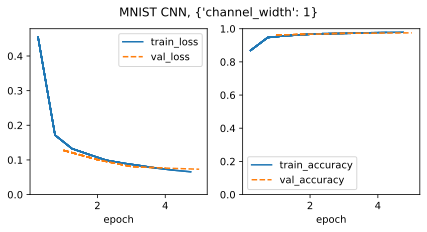

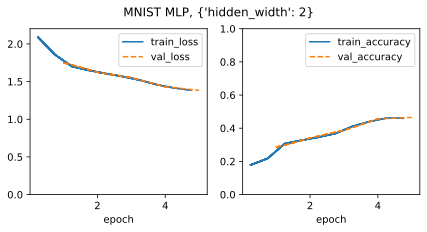

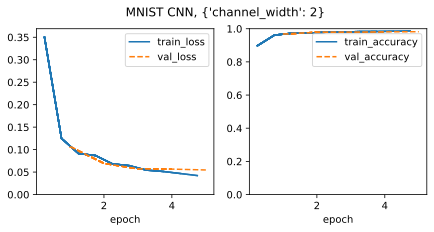

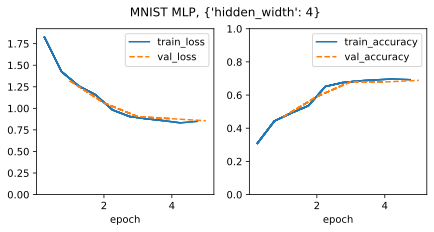

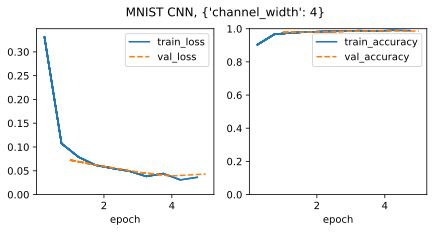

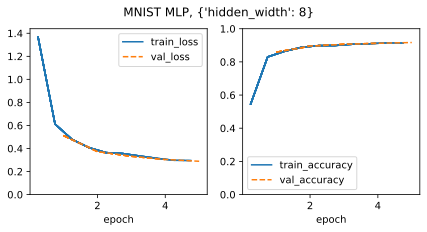

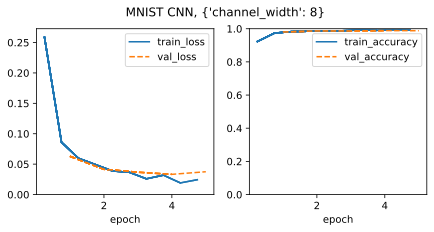

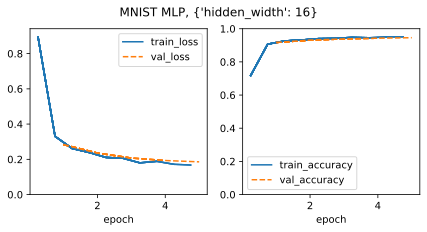

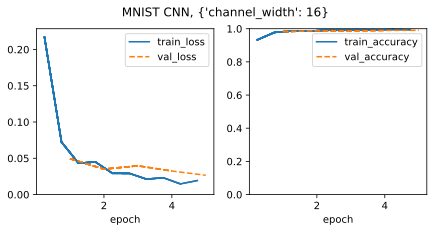

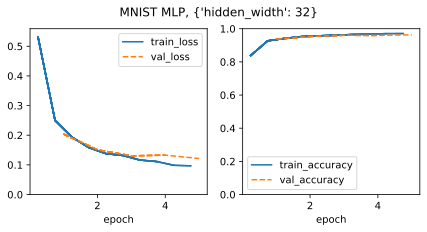

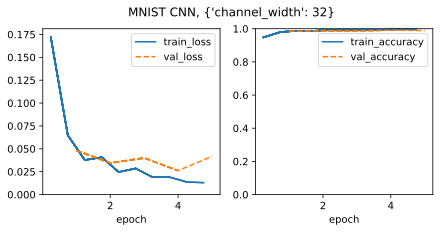

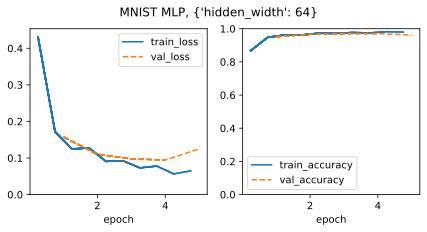

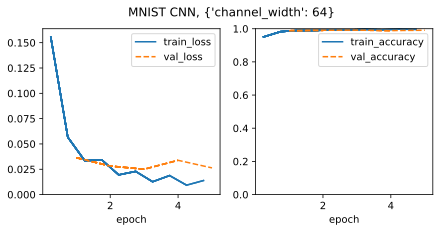

In [13]:
for model_width in model_width_sweep:
    mlp_hp = get_hp('MLP', 'MNIST', hidden_width=model_width)
    cnn_hp = get_hp('CNN', 'MNIST', channel_width=model_width)
    mlp_model = fit(mlp_hp, device=device)
    cnn_model = fit(cnn_hp, device=device)
    _, mlp_val_accuracy = val_stats(mlp_model, mlp_hp, device=device)
    _, cnn_val_accuracy = val_stats(cnn_model, cnn_hp, device=device)
    mlp_val_accuracies[1][0].append(mlp_val_accuracy)
    cnn_val_accuracies[1][0].append(cnn_val_accuracy)
plt.show()

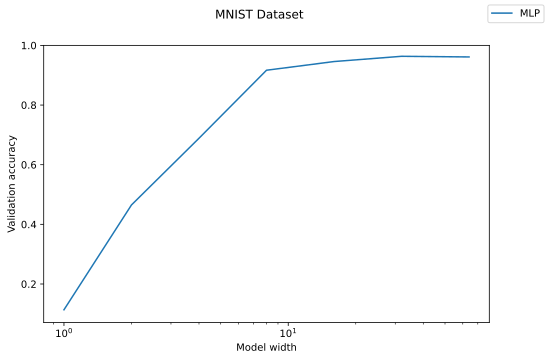

In [14]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(model_width_sweep, mlp_val_accuracies[1][0], label="MLP")
axs.set_xlabel("Model width")
axs.set_ylabel("Validation accuracy")
axs.set_xscale('log')
axs.set_ylim([None,1])
fig.suptitle('MNIST Dataset')
fig.legend();

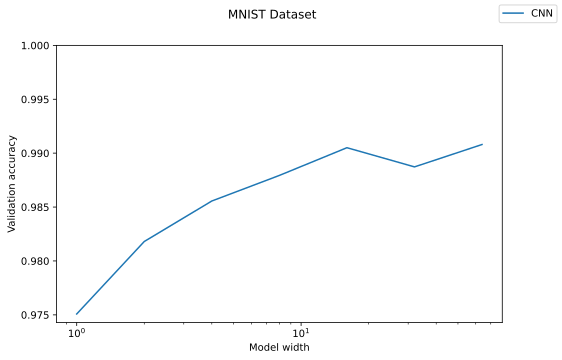

In [15]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(model_width_sweep, cnn_val_accuracies[1][0], label="CNN")
axs.set_xlabel("Model width")
axs.set_ylabel("Validation accuracy")
axs.set_xscale('log')
axs.set_ylim([None,1])
fig.suptitle('MNIST Dataset')
fig.legend();

### Fashion-MNIST Experiments

Sweep 1

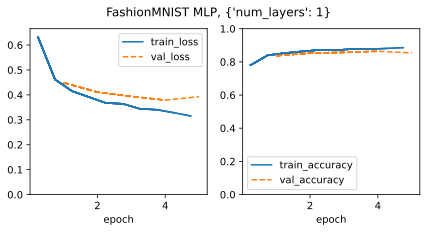

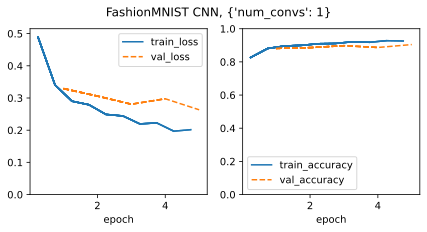

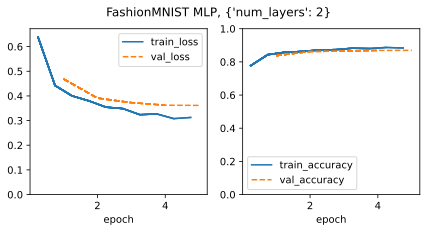

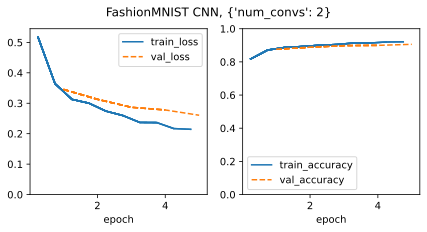

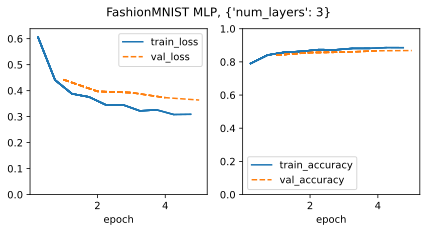

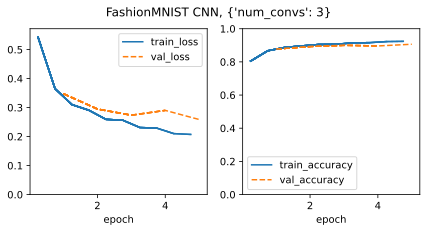

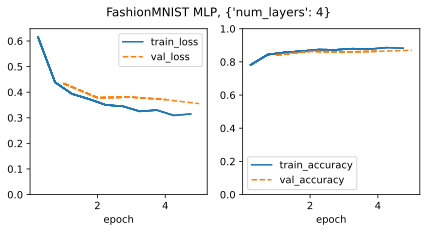

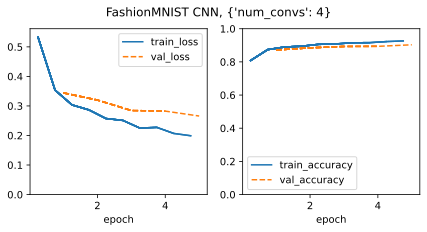

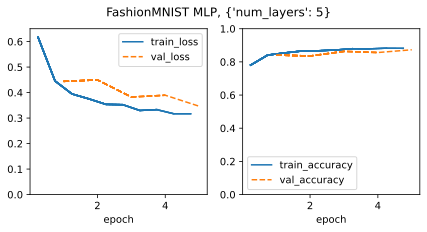

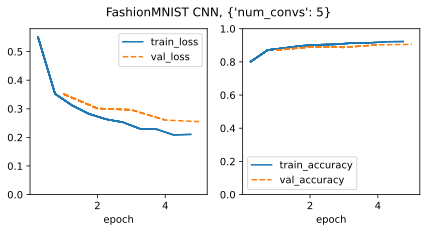

In [16]:
for num_layers in num_layers_sweep:
    mlp_hp = get_hp('MLP', 'FashionMNIST', num_layers=num_layers)
    cnn_hp = get_hp('CNN', 'FashionMNIST', num_convs=num_layers)
    mlp_model = fit(mlp_hp, device=device)
    cnn_model = fit(cnn_hp, device=device)
    _, mlp_val_accuracy = val_stats(mlp_model, mlp_hp, device=device)
    _, cnn_val_accuracy = val_stats(cnn_model, cnn_hp, device=device)
    mlp_val_accuracies[0][1].append(mlp_val_accuracy)
    cnn_val_accuracies[0][1].append(cnn_val_accuracy)
plt.show()

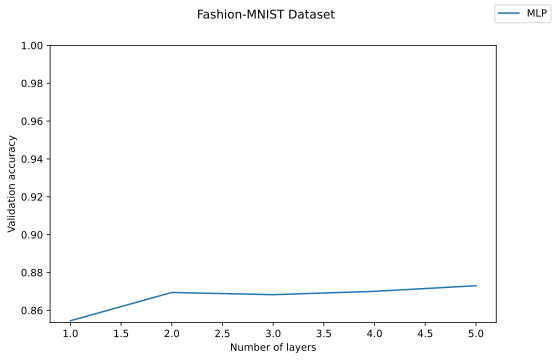

In [17]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(num_layers_sweep, mlp_val_accuracies[0][1], label="MLP")
axs.set_xlabel("Number of layers")
axs.set_ylabel("Validation accuracy")
axs.set_ylim([None,1])
fig.suptitle('Fashion-MNIST Dataset')
fig.legend();

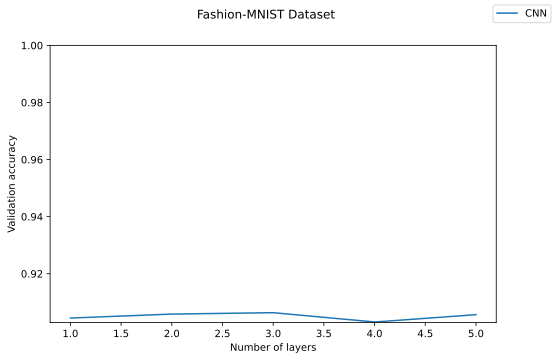

In [18]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(num_layers_sweep, cnn_val_accuracies[0][1], label="CNN")
axs.set_xlabel("Number of layers")
axs.set_ylabel("Validation accuracy")
axs.set_ylim([None,1])
fig.suptitle('Fashion-MNIST Dataset')
fig.legend();

Sweep 2

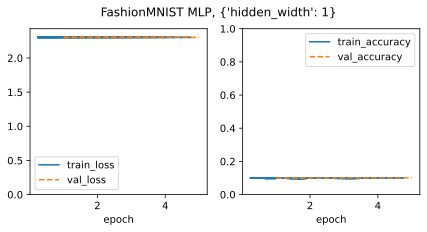

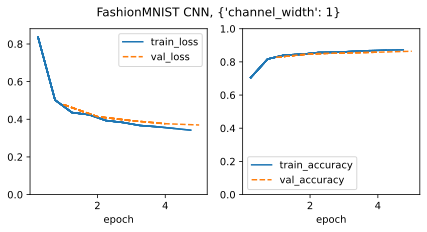

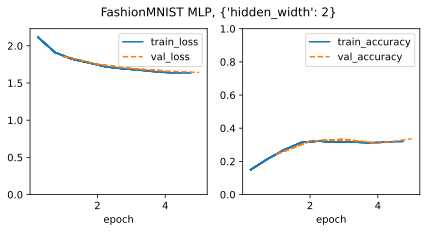

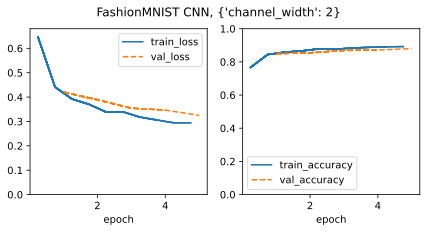

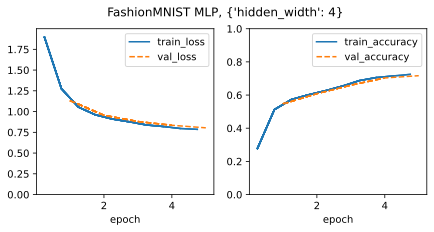

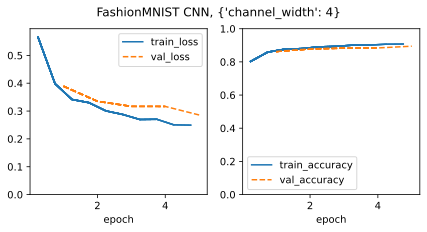

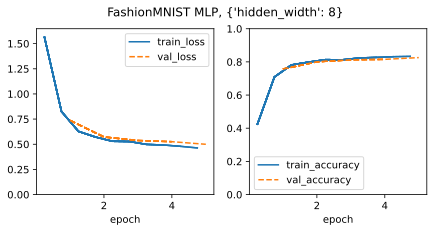

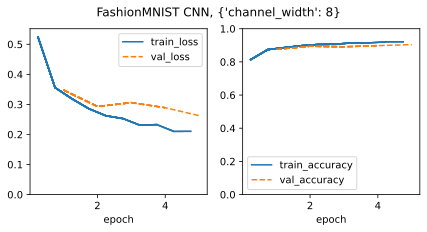

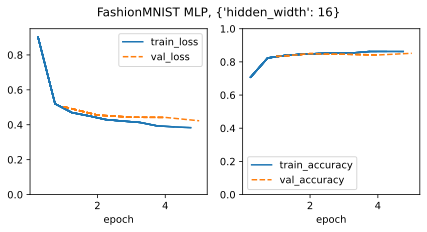

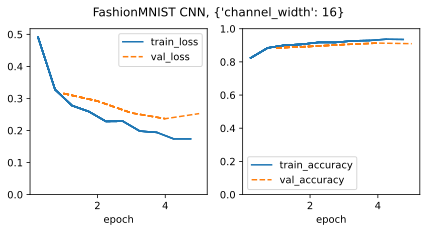

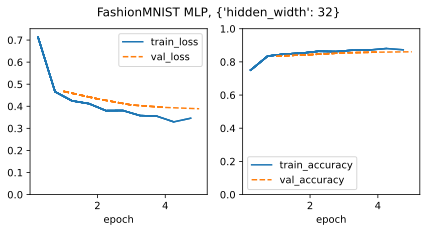

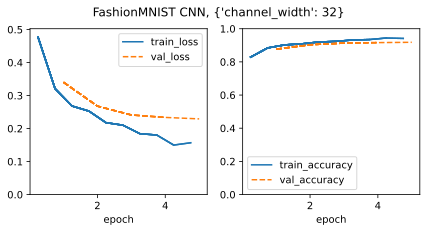

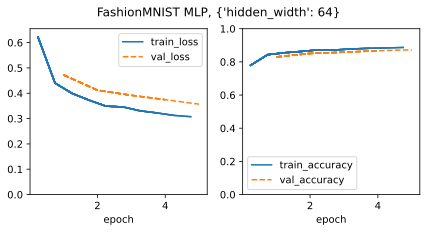

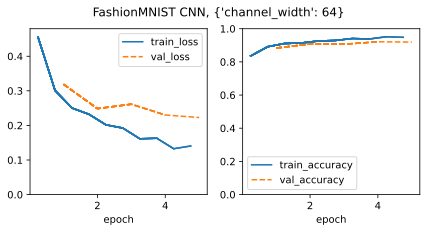

In [19]:
for model_width in model_width_sweep:
    mlp_hp = get_hp('MLP', 'FashionMNIST', hidden_width=model_width)
    cnn_hp = get_hp('CNN', 'FashionMNIST', channel_width=model_width)
    mlp_model = fit(mlp_hp, device=device)
    cnn_model = fit(cnn_hp, device=device)
    _, mlp_val_accuracy = val_stats(mlp_model, mlp_hp, device=device)
    _, cnn_val_accuracy = val_stats(cnn_model, cnn_hp, device=device)
    mlp_val_accuracies[1][1].append(mlp_val_accuracy)
    cnn_val_accuracies[1][1].append(cnn_val_accuracy)
plt.show()

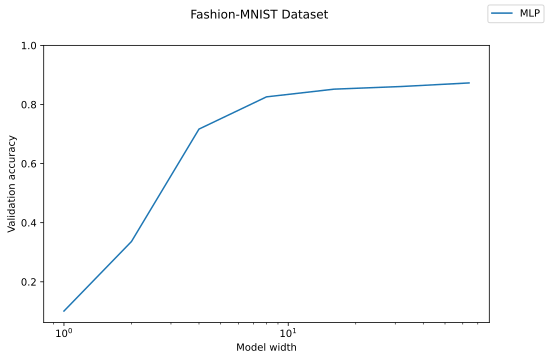

In [20]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(model_width_sweep, mlp_val_accuracies[1][1], label="MLP")
axs.set_xlabel("Model width")
axs.set_ylabel("Validation accuracy")
axs.set_xscale('log')
axs.set_ylim([None,1])
fig.suptitle('Fashion-MNIST Dataset')
fig.legend();

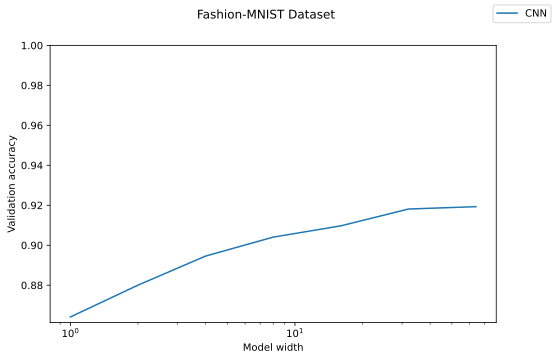

In [21]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(model_width_sweep, cnn_val_accuracies[1][1], label="CNN")
axs.set_xlabel("Model width")
axs.set_ylabel("Validation accuracy")
axs.set_xscale('log')
axs.set_ylim([None,1])
fig.suptitle('Fashion-MNIST Dataset')
fig.legend();

### CIFAR-10 Experiments

Sweep 1

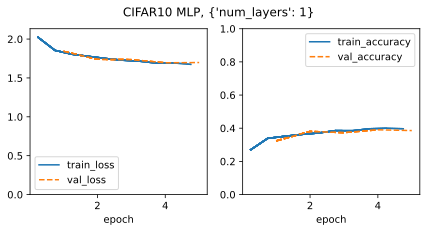

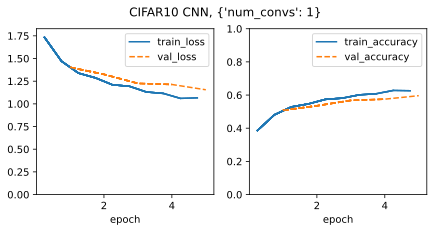

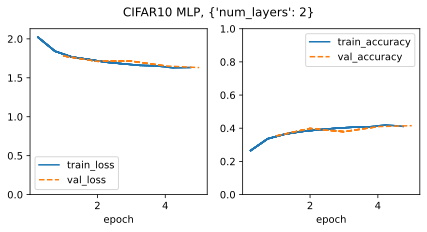

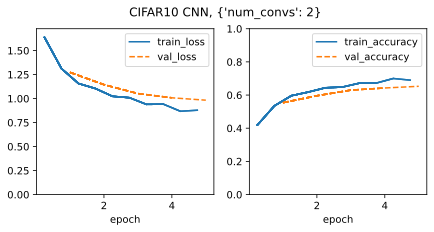

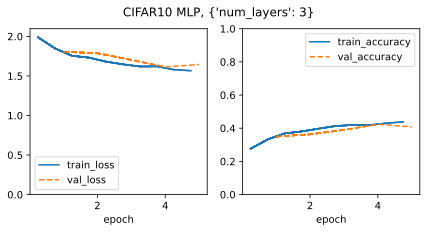

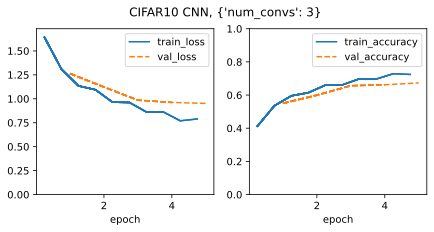

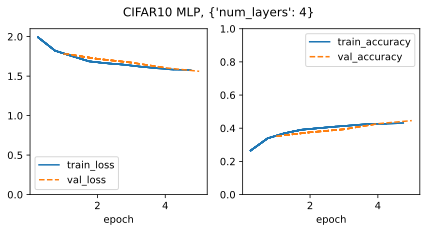

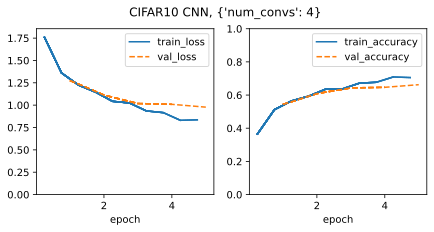

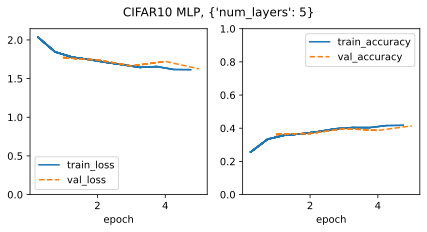

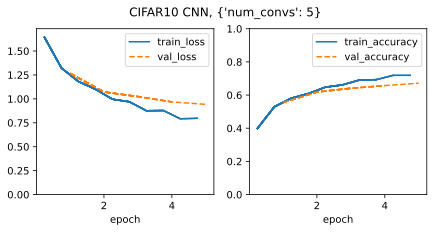

In [22]:
for num_layers in num_layers_sweep:
    mlp_hp = get_hp('MLP', 'CIFAR10', num_layers=num_layers)
    cnn_hp = get_hp('CNN', 'CIFAR10', num_convs=num_layers)
    mlp_model = fit(mlp_hp, device=device)
    cnn_model = fit(cnn_hp, device=device)
    _, mlp_val_accuracy = val_stats(mlp_model, mlp_hp, device=device)
    _, cnn_val_accuracy = val_stats(cnn_model, cnn_hp, device=device)
    mlp_val_accuracies[0][2].append(mlp_val_accuracy)
    cnn_val_accuracies[0][2].append(cnn_val_accuracy)
plt.show()

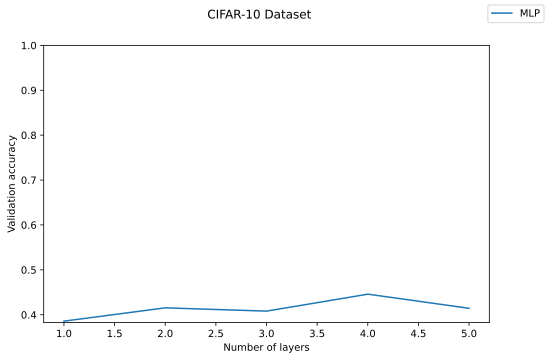

In [23]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(num_layers_sweep, mlp_val_accuracies[0][2], label="MLP")
axs.set_xlabel("Number of layers")
axs.set_ylabel("Validation accuracy")
axs.set_ylim([None,1])
fig.suptitle('CIFAR-10 Dataset')
fig.legend();

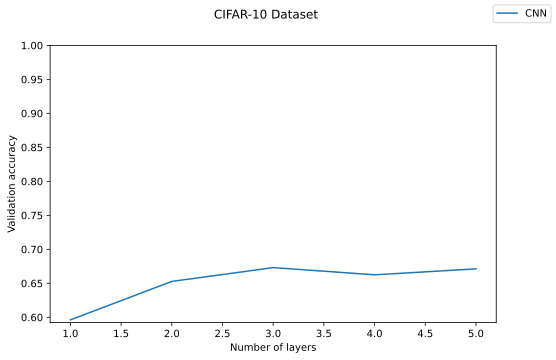

In [24]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(num_layers_sweep, cnn_val_accuracies[0][2], label="CNN")
axs.set_xlabel("Number of layers")
axs.set_ylabel("Validation accuracy")
axs.set_ylim([None,1])
fig.suptitle('CIFAR-10 Dataset')
fig.legend();

Sweep 2

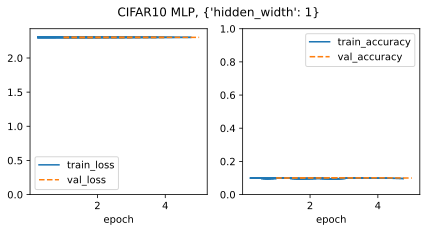

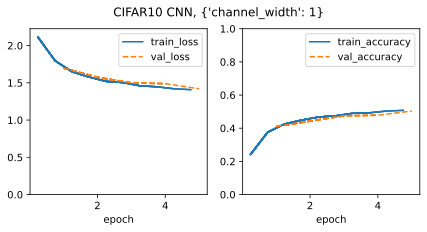

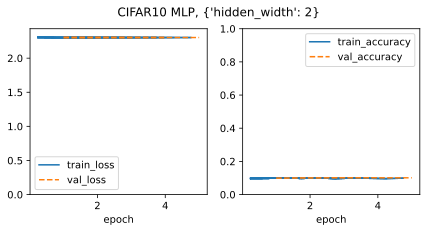

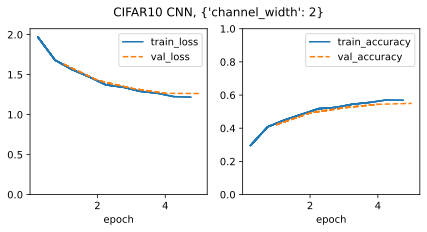

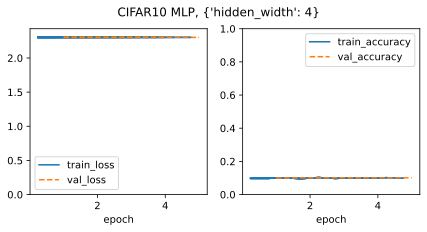

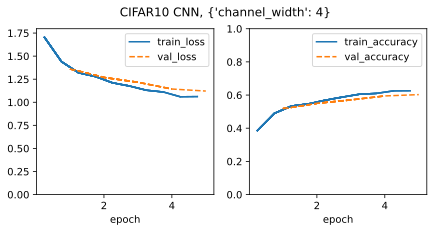

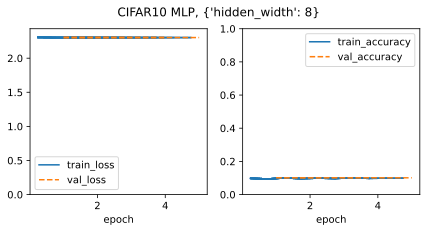

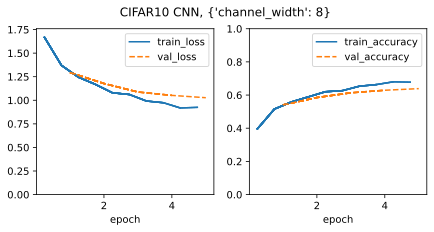

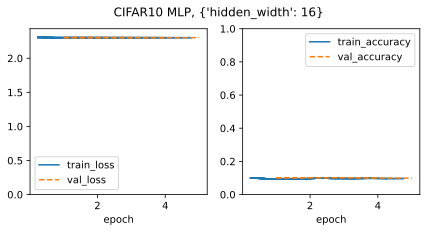

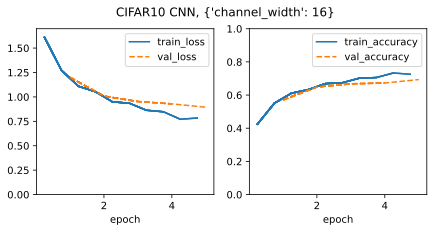

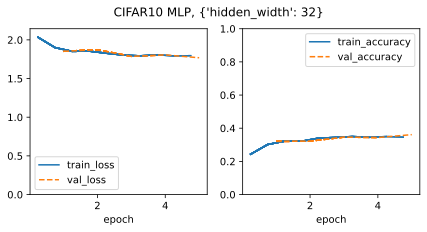

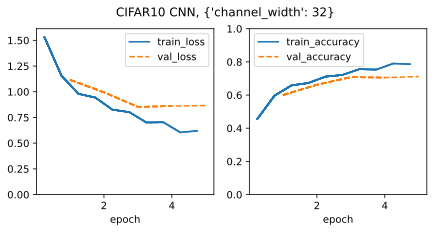

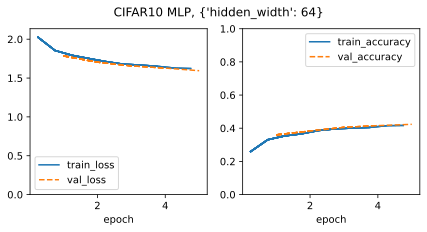

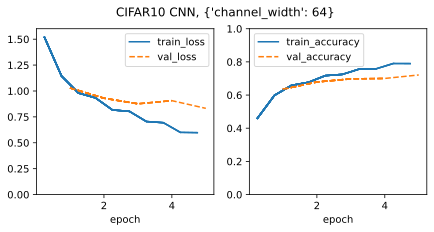

In [25]:
for model_width in model_width_sweep:
    mlp_hp = get_hp('MLP', 'CIFAR10', hidden_width=model_width)
    cnn_hp = get_hp('CNN', 'CIFAR10', channel_width=model_width)
    mlp_model = fit(mlp_hp, device=device)
    cnn_model = fit(cnn_hp, device=device)
    _, mlp_val_accuracy = val_stats(mlp_model, mlp_hp, device=device)
    _, cnn_val_accuracy = val_stats(cnn_model, cnn_hp, device=device)
    mlp_val_accuracies[1][2].append(mlp_val_accuracy)
    cnn_val_accuracies[1][2].append(cnn_val_accuracy)
plt.show()

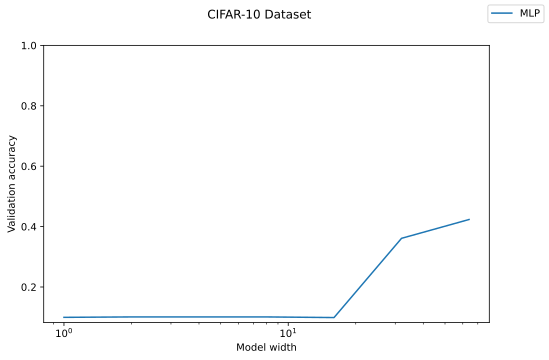

In [26]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(model_width_sweep, mlp_val_accuracies[1][2], label="MLP")
axs.set_xlabel("Model width")
axs.set_ylabel("Validation accuracy")
axs.set_xscale('log')
axs.set_ylim([None,1])
fig.suptitle('CIFAR-10 Dataset')
fig.legend();

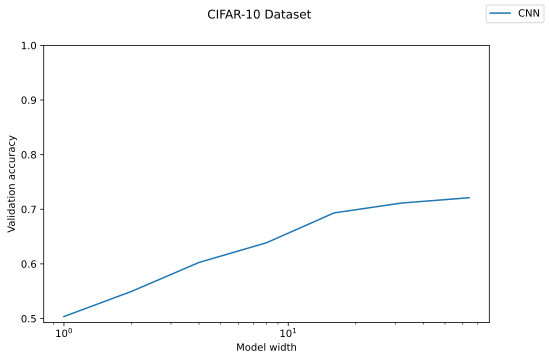

In [27]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(model_width_sweep, cnn_val_accuracies[1][2], label="CNN")
axs.set_xlabel("Model width")
axs.set_ylabel("Validation accuracy")
axs.set_xscale('log')
axs.set_ylim([None,1])
fig.suptitle('CIFAR-10 Dataset')
fig.legend();